<a href="https://colab.research.google.com/github/arthireddy14/AI-Powered-News-Classification-System/blob/main/Articles_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bbc-fulltext-and-category' dataset.
Path to dataset files: /kaggle/input/bbc-fulltext-and-category


In [3]:
import os

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    for file in files[:10]:
        print(file)

Folder: /kaggle/input/bbc-fulltext-and-category
bbc-text.csv


In [4]:
import pandas as pd
import os

print(os.listdir(path))

['bbc-text.csv']


In [5]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/bbc-fulltext-and-category/bbc-text.csv"
)

df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [6]:
print(df.shape)

print(df.columns)

df.info()

(2225, 2)
Index(['category', 'text'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [7]:
print("Total Articles:", len(df))

Total Articles: 2225


In [8]:
print(
    "Number of Categories:",
    df["category"].nunique()
)

Number of Categories: 5


In [9]:
print(df["category"].value_counts())

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [10]:
df["article_length"] = df["text"].apply(
    lambda x: len(str(x).split())
)

In [11]:
print(
    "Average Length:",
    round(df["article_length"].mean(),2)
)

Average Length: 390.3


In [12]:
longest_idx = df["article_length"].idxmax()

print(
    "Longest Article Length:",
    df.loc[longest_idx,"article_length"]
)

print(
    "Category:",
    df.loc[longest_idx,"category"]
)

Longest Article Length: 4492
Category: politics


In [13]:
shortest_idx = df["article_length"].idxmin()

print(
    "Shortest Article Length:",
    df.loc[shortest_idx,"article_length"]
)

print(
    "Category:",
    df.loc[shortest_idx,"category"]
)

Shortest Article Length: 90
Category: politics


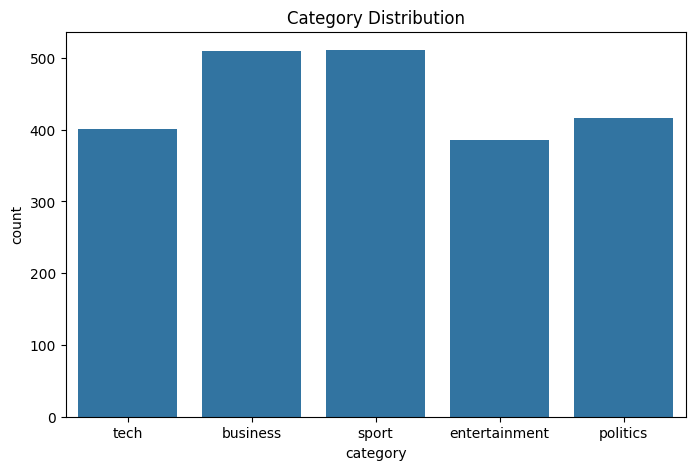

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="category"
)

plt.title("Category Distribution")

plt.show()

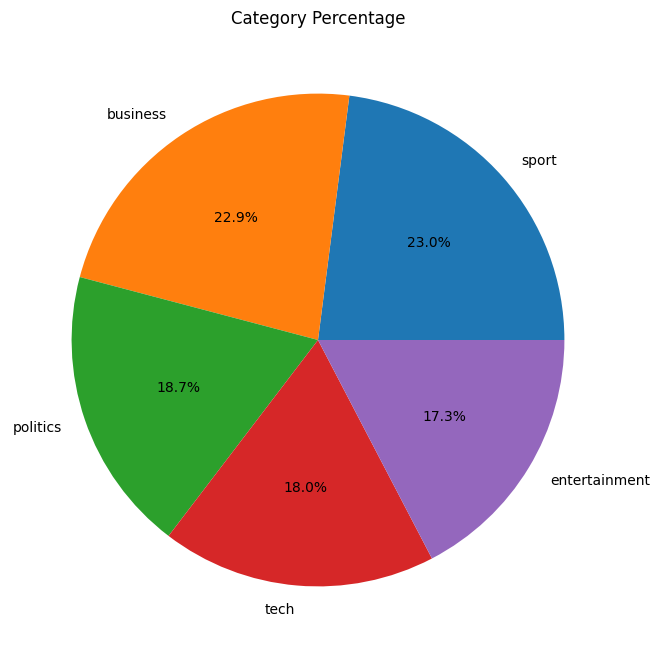

In [15]:
plt.figure(figsize=(8,8))

df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Category Percentage")

plt.show()

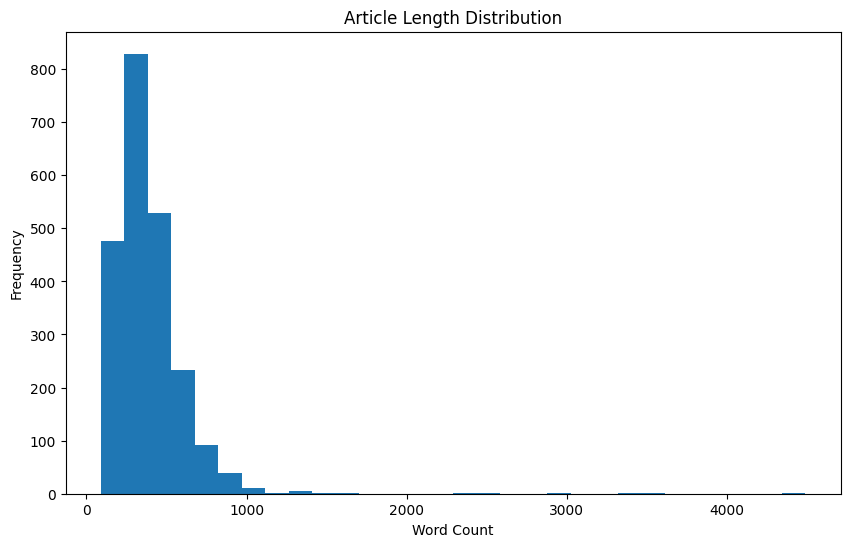

In [16]:
plt.figure(figsize=(10,6))

plt.hist(
    df["article_length"],
    bins=30
)

plt.title("Article Length Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

In [17]:
df["clean_text"] = df["text"].str.lower()

In [18]:
import string

df["clean_text"] = df["clean_text"].apply(
    lambda x: x.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
)

In [19]:
import re

df["clean_text"] = df["clean_text"].apply(
    lambda x: re.sub(
        r'[^a-zA-Z\s]',
        '',
        x
    )
)

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    df["clean_text"]
)

sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

In [21]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 300

X = pad_sequences(
    sequences,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

print(X.shape)

(2225, 300)


In [22]:
label_map = {
    "business":0,
    "politics":1,
    "sport":2,
    "tech":3,
    "entertainment":4
}

In [23]:
df["label"] = df["category"].map(
    label_map
)

df[["category","label"]].head()

,category,label
0,tech,3
1,business,0
2,sport,2
3,sport,2
4,entertainment,4


In [24]:
y = df["label"].values

print(X.shape)
print(y.shape)

(2225, 300)
(2225,)


In [25]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1780, 300)
(445, 300)


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
import time

vocab_size = 10000
embedding_dim = 128

lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=300),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

lstm_time = time.time() - start

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 240ms/step - accuracy: 0.2612 - loss: 1.5534 - val_accuracy: 0.2781 - val_loss: 1.5356
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step - accuracy: 0.3778 - loss: 1.4408 - val_accuracy: 0.3652 - val_loss: 1.4762
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 0.4473 - loss: 1.2478 - val_accuracy: 0.4382 - val_loss: 1.2608
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 225ms/step - accuracy: 0.5239 - loss: 1.0805 - val_accuracy: 0.4326 - val_loss: 1.2326
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 0.6053 - loss: 0.9124 - val_accuracy: 0.5449 - val_loss: 1.2625


In [27]:
lstm_loss, lstm_acc = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Loss:", lstm_loss)
print("Training Time:", lstm_time)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5708 - loss: 1.1149
LSTM Accuracy: 0.5707865357398987
LSTM Loss: 1.1148589849472046
Training Time: 75.16930294036865


In [28]:
from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense,
    LayerNormalization,
    Dropout
)

from tensorflow.keras.models import Model

In [29]:
inputs = Input(shape=(300,))

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=128
)(inputs)

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(
    embedding,
    embedding
)

attention = LayerNormalization()(attention)

pool = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pool)

drop = Dropout(0.3)(dense)

outputs = Dense(
    5,
    activation='softmax'
)(drop)

attention_model = Model(
    inputs,
    outputs
)

attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │     66,048 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 300, 128)  │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,354,885 (5.17 MB)

 Trainable params: 1,354,885 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
start = time.time()

history_attention = attention_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

attention_time = time.time() - start

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 630ms/step - accuracy: 0.4902 - loss: 1.2025 - val_accuracy: 0.9242 - val_loss: 0.3788
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 41s 625ms/step - accuracy: 0.9347 - loss: 0.2108 - val_accuracy: 0.9298 - val_loss: 0.1796
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 607ms/step - accuracy: 0.9565 - loss: 0.1525 - val_accuracy: 0.9073 - val_loss: 0.2361
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 623ms/step - accuracy: 0.9691 - loss: 0.0979 - val_accuracy: 0.9522 - val_loss: 0.1546
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 622ms/step - accuracy: 0.9965 - loss: 0.0155 - val_accuracy: 0.9691 - val_loss: 0.1185


In [31]:
attention_loss, attention_acc = attention_model.evaluate(
    X_test,
    y_test
)

print("Attention Accuracy:", attention_acc)
print("Attention Loss:", attention_loss)
print("Training Time:", attention_time)

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.9663 - loss: 0.0934
Attention Accuracy: 0.966292142868042
Attention Loss: 0.09341026097536087
Training Time: 180.7158501148224


In [32]:
comparison = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Loss",
        "Training Time"
    ],
    "LSTM":[
        lstm_acc,
        lstm_loss,
        lstm_time
    ],
    "Self-Attention":[
        attention_acc,
        attention_loss,
        attention_time
    ]
})

comparison

,Metric,LSTM,Self-Attention
0,Accuracy,0.570787,0.966292
1,Loss,1.114859,0.093410
2,Training Time,75.169303,180.715850


In [33]:
attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)

In [34]:
sample = [
    "Apple launches new AI powered iPhone"
]

In [35]:
seq = tokenizer.texts_to_sequences(sample)

pad = pad_sequences(
    seq,
    maxlen=300,
    padding='post'
)

In [36]:
emb = Embedding(
    vocab_size,
    128
)(inputs)

output, scores = attention_layer(
    emb,
    emb,
    return_attention_scores=True
)

In [37]:
attention_extractor = Model(
    inputs,
    scores
)

In [38]:
scores = attention_extractor.predict(
    pad
)

scores.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


(1, 4, 300, 300)

In [39]:
words = sample[0].split()

for i, word in enumerate(words):
    print(
        word,
        scores.mean(axis=(1,2))[0][i]
    )

Apple 0.0033335208
launches 0.0033333898
new 0.003333302
AI 0.0033333448
powered 0.003333378
iPhone 0.0033333139


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [41]:
heatmap_data = scores[0][0]

length = len(words)

heatmap_data = heatmap_data[
    :length,
    :length
]

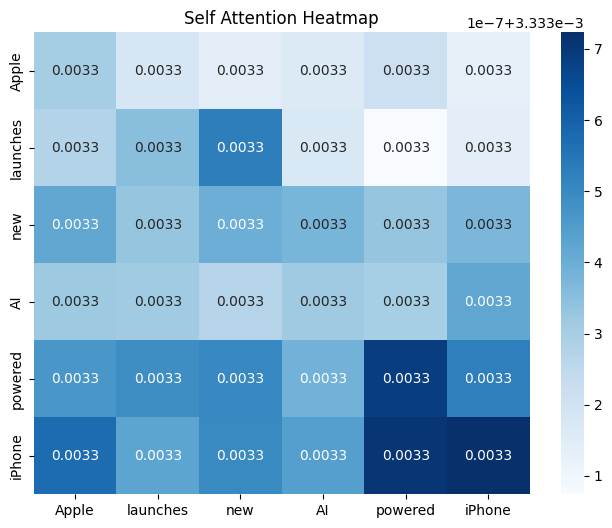

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    cmap="Blues"
)

plt.title(
    "Self Attention Heatmap"
)

plt.show()

In [48]:
attention_model.save(
    "model.h5"
)

In [44]:
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(
        tokenizer,
        f
    )

In [45]:
with open(
    "label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(
        label_map,
        f
    )

In [46]:
import os

print(os.listdir())

['.config', 'tokenizer.pkl', 'label_encoder.pkl', 'model.h5', 'sample_data']
